In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_percentage_error, mean_absolute_error

from scipy.optimize import curve_fit

import random

In [3]:
df = pd.read_excel('./././data/waste_water/all_actual_data.xlsx')

In [4]:
seconds = np.array(df['min'])*60
df['hours'] = df['min']/60
REAL = np.array(df.iloc[1511, 2:-1]).transpose()
df.head()

,min,day,A0('11-25'),A0('9-16' ),A0('9-10'),A0('9-20'),A0('9-24'),A0('9-27'),A0('9-11'),A0('11-28'),...,D('10-28'),D('10-21'),D('11-13'),D('10-24'),D('10-30'),A('9-30'),B('9-30'),C('9-30'),D('9-30'),hours
0,0.0,0.000000,0.0073,0.0000,0.0061,0.0032,0.0107,0.0136,0.0142,0.0061,...,0.0001,0.0014,0.0020,0.0007,0.0002,0.0286,0.0154,0.0086,0.0209,0.000000
1,5.0,0.003472,0.0394,0.0709,0.0035,0.0029,0.0432,0.0332,0.0124,0.0021,...,0.0007,0.0005,0.0028,0.0008,0.0252,0.0327,0.0229,0.0161,0.0195,0.083333
2,10.0,0.006944,0.0744,0.1349,0.0092,0.0099,0.0819,0.0513,0.0044,0.0036,...,0.0000,0.0006,0.0070,0.0013,0.0039,0.0352,0.0271,0.0211,0.0277,0.166667
3,15.0,0.010417,0.0727,0.1605,0.0179,0.0243,0.1011,0.0599,0.0044,0.0075,...,0.0005,0.0007,0.0142,0.0020,0.0029,0.0372,0.0293,0.0251,0.0361,0.250000
4,20.0,0.013889,0.0685,0.1656,0.0416,0.0458,0.1104,0.0649,0.0047,0.0133,...,0.0007,0.0008,0.0264,0.0031,0.0030,0.0386,0.0318,0.0285,0.0440,0.333333


### Функции

In [5]:
# Linear BOI and Q
def D(Q):
  x = (Q - 2.7764)/7.9688
  return x

# def D0(Q):
#   # x = (Q - 22.355)/10.93
#   x = (Q + 63.3995)/10.8707
#   return x

# def D0(Q):
#   x = (Q - 22.355)/10.93
#   return x

def D0(Q):
  x = (Q + 31.9236)/8.9363
  return x

def A0(Q):
  x = (Q + 39.478)/9.862
  return x

def A(Q):
  x = (Q + 16.548)/7.9411
  return x

def B0(Q):
  x = (Q + 41.036)/9.9758
  return x

def B(Q):
  x = (Q + 10.56)/7.9659
  return x

def C0(Q):
  x = (Q + 30.168)/8.7912
  return x

def C(Q):
  x = (Q + 18.662)/7.3071
  return x


def renorm(_data, _max, _min):
  return _data*(_max-_min)+_min

def Renormalize(_data, _max, _min):
  renormalize_data = pd.DataFrame()
  for i in range(0, _data.shape[1]-1):
    renormalize_data[_data.columns[i+1]] = renorm(_data.iloc[:, i+1], _max[i], _min[i])
  return renormalize_data


def norm(_data):
    return (_data-_data[1:].min())/(_data.max()-_data[1:].min())



def left_rect(x, f):
  _charge = []
  sum_charge = 0
  h = x[1]-x[0]

  for i in range(0, f.shape[0]):
    sum_charge += h*f[i]
    _charge.append(sum_charge)
  return _charge


def dynamic_function_call(prefix, value):
    """Динамически вызывает функцию по названию префикса."""
    function_name = prefix.strip()
    if function_name in globals():
        return globals()[function_name](value)
    else:
        raise ValueError(f"Функция {function_name} не найдена.")

def BOI(_charge):
    results = []
    for col in _charge.columns:
        prefix = col.split('(')[0]
        values = _charge[col].dropna().values
        if len(values) > 0:
            result = dynamic_function_call(prefix, values[-1])
            results.append(result)
    return results

def percentage_estimate(real_boi, pred_boi):
  _mape = []
  for i in range(0, len(pred_boi)):
    _mape.append(mean_absolute_percentage_error([real_boi[i]], [pred_boi[i]]))
  return _mape

def charge(_x, _data):
  _charge = pd.DataFrame()
  _charge['long'] = pd.Series([i for i in range(1511)])
  for i in range(_data.shape[1]):
    q = left_rect(_x, _data.iloc[:, i].values[:np.count_nonzero(~np.isnan(_data.iloc[:, i].values))]/100)
    _charge[_data.columns[i]] = q + [None] * (1511 - len(q))

  _charge.drop('long', axis=1, inplace=True)
  return _charge

def Normalize(k, _data, _max_index):
  normalize_data = pd.DataFrame()
  normalize_data['long'] = pd.Series([i for i in range(1511)])
  for i in range(_data.shape[1]):
    normalize_data[_data.columns[i]] = norm(_data.iloc[1:k[i], i])

  max_values = []
  min_values = []

  for i in range(_data.shape[1]):
    max_values.append(_data.iloc[_max_index[i], i])
    min_values.append(_data.iloc[1:k[i], i].min())
  normalize_data.drop('long', axis=1, inplace=True)
  normalize_data.drop(normalize_data.index[0], axis=0, inplace=True)

  return (normalize_data, max_values, min_values)

### Берём временные ряды, которые будем аппроксимировать

In [6]:
choice_data = df.iloc[:-1, 2:-1]

choice_data = choice_data.iloc[:, np.r_[:27, 57:66]]
REAL = REAL[np.r_[:27, 57:66]]

In [7]:
def find_indices_multiple_columns(db, initial_points=12, total_points=289):
    results = {}

    for column in db.columns:
        current_index = 12
        indices = []
        initial_points=12
        total_points=289

        while (current_index < len(db)) and (len(indices) < total_points):
            end_index = current_index + initial_points

            if end_index > len(db):
                break

            points = db[column][current_index:end_index]

            derivative = np.diff(points)
            mean_derivative = np.mean(derivative)


            if mean_derivative < 0:
                indices.append(end_index)
                break
            else:
                current_index += 4

            if initial_points > 260:
                indices.append(144)
                break
        if not indices:
            indices.append(144)
        results[column] = indices

    return results

result_indices = find_indices_multiple_columns(choice_data.iloc[:289, :])

`result_indices` - словарь с ключами - названиями колонок, значениями - первыми точками, после которых начинается устойчивое убывание значений (отрицательная средняя производная). Если такая точка не найдена, возвращает индекс 144.

In [8]:
result_indices

{"A0('11-25')": [24],
 "A0('9-16' )": [24],
 "A0('9-10')": [24],
 "A0('9-20')": [24],
 "A0('9-24')": [24],
 "A0('9-27')": [52],
 "A0('9-11')": [160],
 "A0('11-28')": [216],
 "A0('10-03')": [176],
 "B0('11-25')": [24],
 "B0('9-16')": [24],
 "B0('9-10')": [24],
 "B0('9-20')": [24],
 "B0(9-24')": [24],
 "B0('9-27')": [32],
 "B0('9-11')": [184],
 "B0('11-28')": [192],
 "B0('10-03')": [256],
 "C0('11-25')": [24],
 "C0('9-16')": [24],
 "C0('9-10')": [24],
 "C0('9-20')": [24],
 "C0('9-24')": [24],
 "C0('9-27')": [48],
 "C0('9-11')": [152],
 "C0('11-28')": [256],
 "C0('10-03')": [144],
 "D0('11-25')": [24],
 "D0('9-16' )": [28],
 "D0('9-10')": [24],
 "D0('9-20')": [28],
 "D0('9-24')": [32],
 "D0('9-27')": [52],
 "D0('9-11')": [144],
 "D0('11-28')": [120],
 "D0('10-03')": [108]}

In [9]:
choice_data

,A0('11-25'),A0('9-16' ),A0('9-10'),A0('9-20'),A0('9-24'),A0('9-27'),A0('9-11'),A0('11-28'),A0('10-03'),B0('11-25'),...,C0('10-03'),D0('11-25'),D0('9-16' ),D0('9-10'),D0('9-20'),D0('9-24'),D0('9-27'),D0('9-11'),D0('11-28'),D0('10-03')
0,0.0073,0.0000,0.0061,0.0032,0.0107,0.0136,0.0142,0.0061,0.0103,0.0095,...,0.0089,0.0072,0.0125,0.0187,0.0131,0.0379,0.0820,0.0669,0.0048,0.0176
1,0.0394,0.0709,0.0035,0.0029,0.0432,0.0332,0.0124,0.0021,0.0014,0.0963,...,0.0016,0.0677,0.0227,0.0237,0.0095,0.0807,0.0399,0.0664,0.0020,0.0230
2,0.0744,0.1349,0.0092,0.0099,0.0819,0.0513,0.0044,0.0036,0.0010,0.1526,...,0.0013,0.1137,0.0522,0.0354,0.0148,0.1162,0.0858,0.0388,0.0058,0.0228
3,0.0727,0.1605,0.0179,0.0243,0.1011,0.0599,0.0044,0.0075,0.0009,0.1437,...,0.0011,0.1275,0.1009,0.0555,0.0273,0.1278,0.1351,0.0306,0.0115,0.0263
4,0.0685,0.1656,0.0416,0.0458,0.1104,0.0649,0.0047,0.0133,0.0010,0.1275,...,0.0011,0.1287,0.1275,0.0858,0.0534,0.1354,0.1491,0.0299,0.0182,0.0299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0200,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0231
1507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0199,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0231
1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0198,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0230
1509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0199,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0231


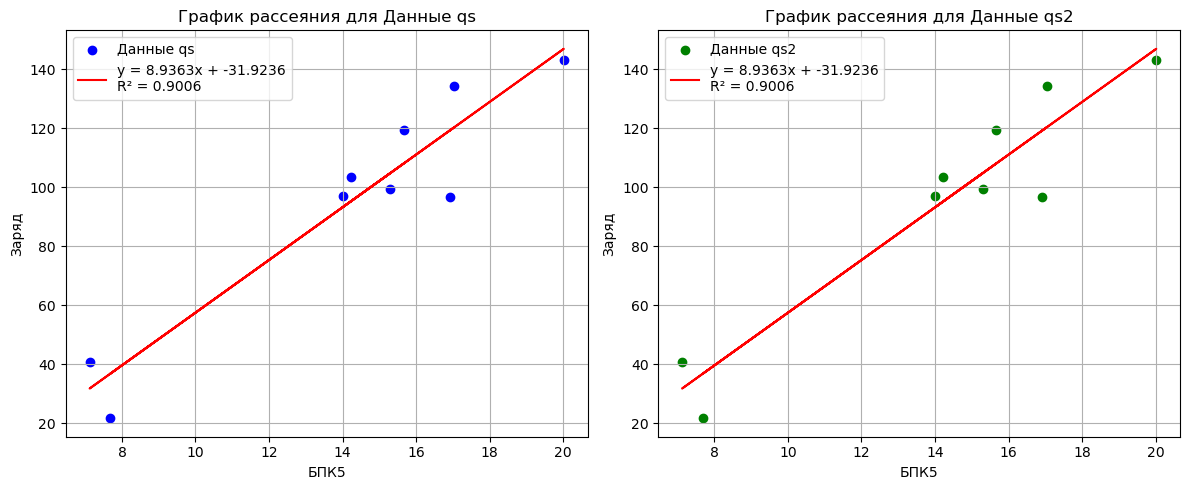

In [10]:
all_integral_deviations = []
all_shifted_series = []


for k in range(9):
    ts1 = choice_data.iloc[:, k]
    ts2 = choice_data.iloc[:, k+9]
    ts3 = choice_data.iloc[:, k+18]
    ts4 = choice_data.iloc[:, k+27]  

    median_ts = pd.concat([ts1, ts2, ts3], axis=1).median(axis=1)
    

    integral_deviation = np.sum(np.abs(ts4 - median_ts))
    all_integral_deviations.append(integral_deviation)

    if k == 6:
        shifted_ts4 = ts4 * 0.2
    else:
        shifted_ts4 = ts4 - np.mean((ts4 - median_ts).dropna())

    all_shifted_series.append(shifted_ts4)


correct_D1 = pd.DataFrame(all_shifted_series).T


for j in [0, 1, 2, 3, 4, 5, 6, 7, 8]:
    idx = correct_D1.iloc[289:, j].where(lambda x: x <= 0.02).first_valid_index()
    if j == 5:
        idx = choice_data.iloc[:, 32].last_valid_index()
    if idx:
        correct_D1.iloc[idx:, j] = np.nan

correct_D1[correct_D1 < 0] = 0
Q_real = charge(seconds[:-1], correct_D1.fillna(0))
boi_real = BOI(Q_real)
integrals = Q_real.iloc[-1, :].values
b = (integrals+19.5097)/8.3632
err_d = 100*np.abs(b - df.iloc[-1, 59:68].values)/np.abs(df.iloc[-1, 59:68].values)
err_d = np.round(err_d, 3)

k1, k2 = 0, 9
xs = [REAL[k1:k2], REAL[k1:k2]]
y_data = [integrals[k1:k2], integrals[k1:k2]]
labels = ['Данные qs', 'Данные qs2']
colors = ['blue', 'green']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, x, y, label, color in zip([ax1, ax2], xs, y_data, labels, colors):
    ax.scatter(x, y, label=label, color=color)

    coefficients = np.polyfit(x, y, 1)
    polynomial = np.poly1d(coefficients)
    y_fit = polynomial(x)
    r2 = r2_score(y, y_fit)

    ax.plot(x, y_fit, color='red',
            label=f'y = {coefficients[0]:.4f}x + {coefficients[1]:.4f}\nR² = {r2:.4f}')

    ax.set_xlabel('БПК5')
    ax.set_ylabel('Заряд')
    ax.set_title(f'График рассеяния для {label}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
choice_data.iloc[:, 27:] = correct_D1

In [12]:
idp = np.squeeze(list(result_indices.values()))
# indexes of maximum function values
maxes = np.array([choice_data.iloc[:idp[i], i].idxmax() for i in range(choice_data.shape[1])])
max1 = maxes

In [13]:
from sklearn.preprocessing import MinMaxScaler

normalized_data = choice_data.copy()

scaler = MinMaxScaler()

DataAll, MaxAll, MinAll = pd.DataFrame(
    scaler.fit_transform(choice_data),
    columns=choice_data.columns,
    index=choice_data.index
), scaler.data_min_, scaler.data_max_ 

`Аппроксимиривание по участкам`

In [14]:
from my_package.data_structurs import *
from my_package.approximation import *
from my_package.utils import PipelineLoader

In [ ]:
def model_for_synthesis(x, sigma1, mu1, lambda1, sigma2, mu2, lambda2):
    lognormal_part = lambda1 * (np.exp(-((np.log(x) - mu1)**2) / (2 * sigma1**2)) / (x * sigma1 * np.sqrt(2 * np.pi)))
    normal_part = lambda2 * (np.exp(-((x - mu2)**2) / (2 * sigma2**2)) / (sigma2 * np.sqrt(2 * np.pi)))
    return lognormal_part + normal_part

# другая функция
def extrapolate_model(x, sigma, mu, a, b):
  return (np.exp(-((np.log(x) - mu)**2) / (2 * sigma**2)) / (x * sigma * np.sqrt(2 * np.pi))) - a/(b + x**2)

def run_pipeline(pipeline_loader:PipelineLoader):
    result = []
    for func, mapping, parametres, bounds in pipeline_loader:
        approx = search_most_viable_parametres(func, mapping, parametres, bounds, False)
        
        result.append(approx)

    return result

def get_parametres_from_pipeline(results_approx:list):
    results_parametres = pd.DataFrame()
    for res in results_approx:
        local_params = res.parametres_show()
        results_parametres = pd.concat([results_parametres, local_params], ignore_index=True)

    return results_parametres

def get_values_piecewise_approximation(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.y_approx]

    return all_values

# def piecewise_func(x, results_approx:list):
#     y = np.array([])
#     for res in results_approx:
#         y = np.r_[y, res.func(x, *res.params)]

#     return y

In [ ]:
def coeff_search(_data, _right, _left):
    approximate = pd.DataFrame()
    coeff = pd.DataFrame()
    approximate['long'] = df.iloc[1:-1, 1]
    
    for i in range(0, _data.shape[1]):

        param = (1.5, np.log(df.iloc[1:_data.iloc[:-1, i].count()+1, 1].iloc[-1]), 0.5, 0.5, df.iloc[1:_data.iloc[:-1, i].count()+1, 1].iloc[-1], 0.5)
        lst1 = [0.05, -5, 0.05, 0.05, 0.05, 0.05]
        lst2 = [3.5, np.log(df.iloc[1:_data.iloc[:-1, i].count()+1, 1].iloc[-1]), 3, 3, df.iloc[1:_data.iloc[:-1, i].count()+1, 1].iloc[-1], 1.5]

        independent_vals_count = df.iloc[1:_data.iloc[:-1, i].count()+1, 1].to_numpy().shape[0]
        independent_vals = df.iloc[1:_data.iloc[:-1, i].count()+1, 1].to_numpy()

        pipeline_change = StructurePipelineApproximation(
            ['model_for_synthesis_segm1', 'model_for_synthesis_segm2'],
            [model_for_synthesis, model_for_synthesis],
            [[0, independent_vals[independent_vals_count//2]], [independent_vals[independent_vals_count//2], 7]],
            [param, param],
            [(lst1, lst2), (lst1, lst2)]
        )

        now_mapping = Mapping(
            df.iloc[1:_data.iloc[:-1, i].count()+1, 1].to_numpy(),
            _data.iloc[0:_data.iloc[:-1, i].count(), i].to_numpy(),
            False
        )

        pipeline = PipelineLoader(now_mapping, pipeline_change)

        all_result = run_pipeline(pipeline)

        coeff = pd.concat([coeff, get_parametres_from_pipeline(all_result)])

        approximate_new_size = np.r_[get_values_piecewise_approximation(all_result), np.zeros(1510 - df.iloc[1:_data.iloc[:-1, i].count()+1, 1].to_numpy().shape[0])]

        approximate[_data.columns[i]] = approximate_new_size
    
    return approximate, coeff

_approxAll, coeffAll = coeff_search(DataAll, [-1 for _ in range(DataAll.shape[1])], np.zeros(DataAll.shape[1]).astype(int))
_approxAll.drop('long', axis=1, inplace=True)
# approxAll = Renormalize(_approxAll, MaxAll, MinAll)
approxAll  = pd.DataFrame(
    scaler.inverse_transform(_approxAll),
    columns=_approxAll.columns,
    index=_approxAll.index
)

# approxAll[approxAll < 0] = 0

# coeffAll.loc[len(coeffAll)] = MaxAll
# coeffAll.loc[len(coeffAll)] = MinAll
# coeffAll.loc[len(coeffAll)] = choice_data.count()

# cof = coeffAll.T
# cof.columns = ['sigma', 'mu', 'lambda1', 'sigma2', 'mu2', 'lambda2', 'max', 'min', 'len']

# from scipy import integrate
# cof['integral'] = approxAll.fillna(0).apply(lambda col: integrate.simpson(col, x=approxAll.index))

# cof['cluster'] = [0 if col[1] == '0' else 1 for col in choice_data.columns]
# cof['BOD'] = REAL

In [17]:
coeffAll

,coef_peak,mu,sigma,free_term
0,3.500000,-1.257369,2.304614,0.100000
1,2.102148,1.437891,1.707342,0.050000
0,3.500000,-1.664119,1.516600,0.100000
1,3.500000,-2.839183,2.899077,0.084407
0,3.500000,-1.361784,0.965662,0.100000
...,...,...,...,...
1,3.500000,0.718856,1.485445,0.100000
0,2.166437,0.766353,0.899853,0.050000
1,3.500000,0.145954,1.540715,0.100000
0,3.417932,0.846947,1.484560,0.050000


C:\Users\obyde\AppData\Local\Temp\ipykernel_20820\611293450.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend()


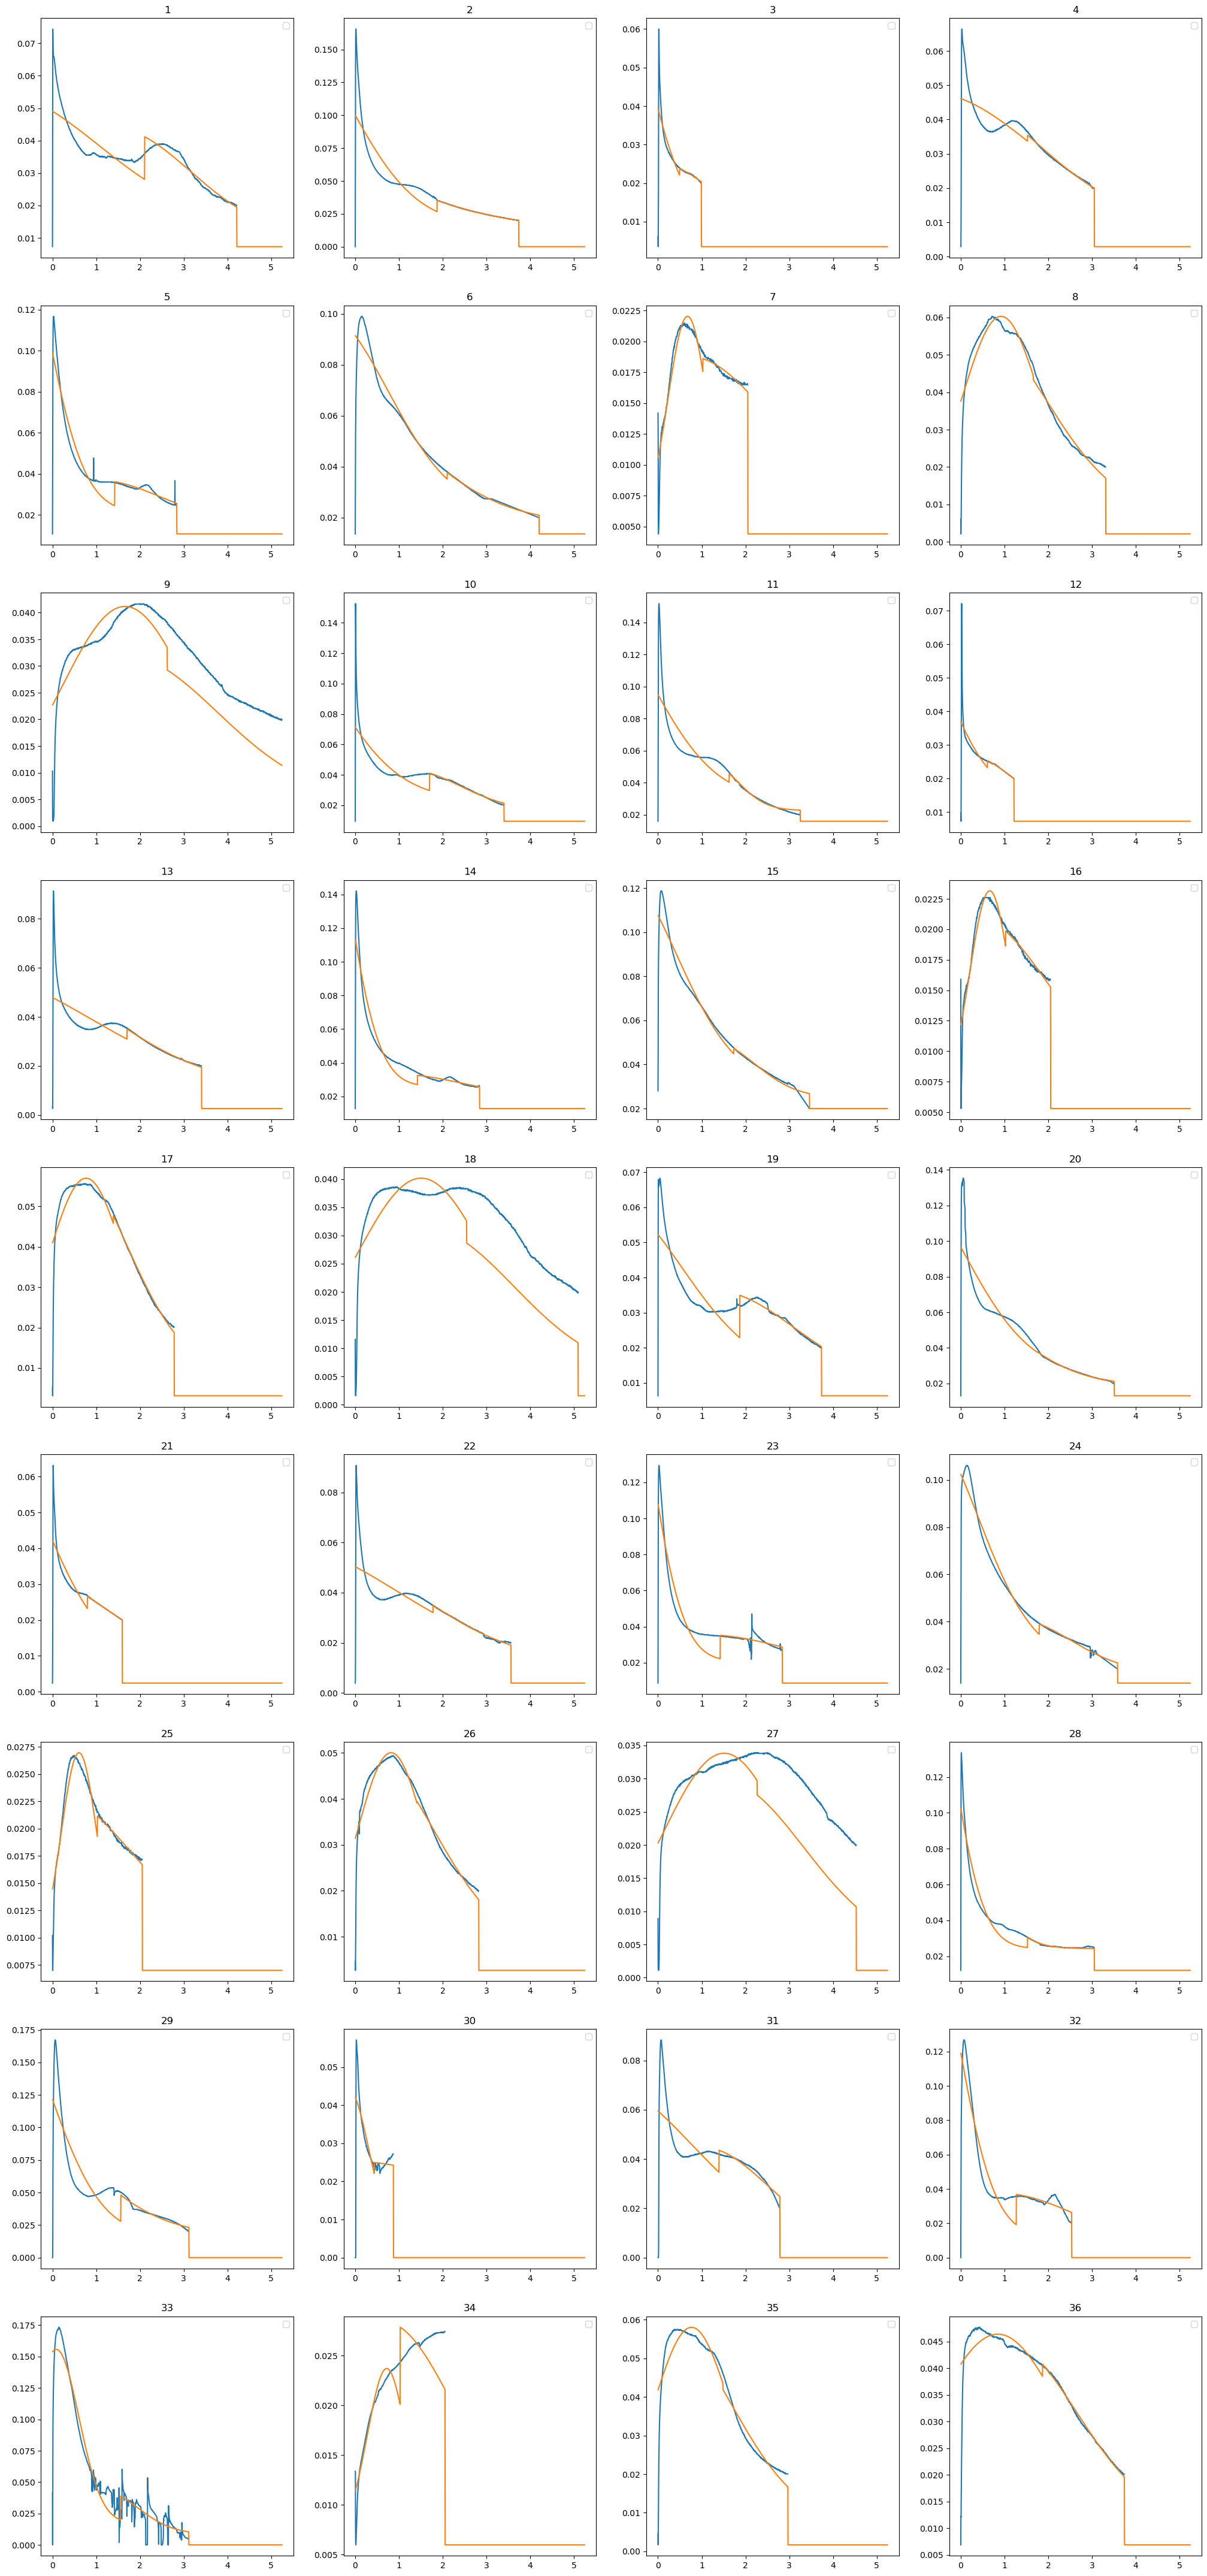

In [19]:
fig, ax = plt.subplots(9, 4, figsize=(25, 55))
axs = [ax[i, j] for i in range(9) for j in range(4)]
for i in range(0, 36):
    axs[i].plot(df.iloc[:1511, 1], choice_data.iloc[:1511, i])
    axs[i].plot(df.iloc[1:approxAll.iloc[:, i].size+1, 1], approxAll.iloc[:, i])
    axs[i].set_title(str(i+1))
    axs[i].legend()